## MAYBAKER STOCK PRICE PREDICTION

In [1]:
## to change the name across the code
## ctrl + h will open the tab the fill the new name in replace
## to change the name across the entire code so you dont have to click enter everytime
## ctrl + shift + h

import pandas as pd

maybaker=pd.read_csv('../stock_data/maybaker.csv') ## so it can be small letter. This is cool.
maybaker=maybaker.drop(columns=['high_price','low_price'])
maybaker.rename(columns={'trade_date':'date'},inplace=True)
maybaker['date']=pd.to_datetime(maybaker['date'])
maybaker['month']=maybaker['date'].dt.month
maybaker['quarter']=maybaker['date'].dt.quarter
maybaker['year']=maybaker['date'].dt.year

maybaker

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,42833,MAYBAKER,2017-01-03,0.94,0.94,37275,2026-04-08T02:41:25.765521+00:00,1,1,2017
1,43393,MAYBAKER,2017-01-04,0.94,0.94,53654,2026-04-08T02:42:20.164398+00:00,1,1,2017
2,43503,MAYBAKER,2017-01-05,0.94,0.94,2800,2026-04-08T02:42:22.380516+00:00,1,1,2017
3,43613,MAYBAKER,2017-01-06,0.94,0.94,23340,2026-04-08T02:42:23.84796+00:00,1,1,2017
4,43703,MAYBAKER,2017-01-09,0.94,0.94,44400,2026-04-08T02:42:26.938159+00:00,1,1,2017
...,...,...,...,...,...,...,...,...,...,...
2258,298090,MAYBAKER,2026-07-13,38.00,38.00,383117,2026-07-13T15:10:02.995074+00:00,7,3,2026
2259,298528,MAYBAKER,2026-07-14,38.00,38.00,278941,2026-07-14T15:10:03.094441+00:00,7,3,2026
2260,298966,MAYBAKER,2026-07-15,38.00,38.00,313749,2026-07-15T15:10:03.078609+00:00,7,3,2026
2261,299404,MAYBAKER,2026-07-16,39.00,39.00,613679,2026-07-16T15:10:03.113936+00:00,7,3,2026


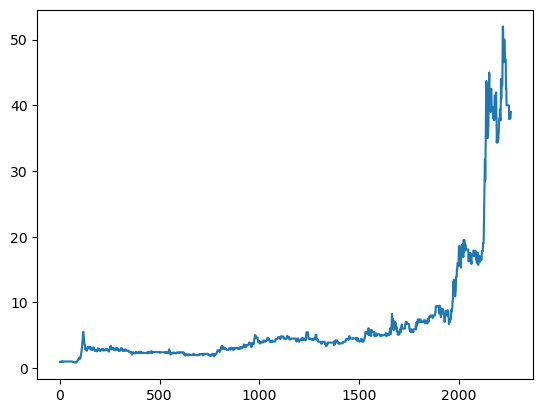

In [2]:
import matplotlib.pyplot as plt

plt.plot(maybaker['close_price'])
plt.show()

In [3]:
maybaker_end_month_df = (
    maybaker
    .sort_values("date")
    .groupby(maybaker["date"].dt.to_period("M"))
    .tail(1)
    .reset_index(drop=True)
)

maybaker_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,45403,MAYBAKER,2017-01-31,1.00,1.00,138601,2026-04-08T02:43:03.07753+00:00,1,1,2017
1,47225,MAYBAKER,2017-02-28,1.00,1.00,4000,2026-04-08T02:44:45.006295+00:00,2,1,2017
2,49341,MAYBAKER,2017-03-31,0.95,0.95,150400,2026-04-08T02:45:42.281198+00:00,3,1,2017
3,51168,MAYBAKER,2017-04-28,0.85,0.85,11400,2026-04-08T02:51:55.619599+00:00,4,2,2017
4,53091,MAYBAKER,2017-05-31,1.49,1.49,568015,2026-04-08T02:52:57.421655+00:00,5,2,2017
...,...,...,...,...,...,...,...,...,...,...
110,35327,MAYBAKER,2026-03-31,38.00,38.00,788842,2026-03-31T15:00:02.085058+00:00,3,1,2026
111,281153,MAYBAKER,2026-04-30,37.70,37.70,1706180,2026-04-30T15:00:02.170664+00:00,4,2,2026
112,284219,MAYBAKER,2026-05-29,46.70,46.70,452486,2026-05-29T15:00:02.455558+00:00,5,2,2026
113,294147,MAYBAKER,2026-06-30,40.00,40.00,234562,2026-06-30T15:10:03.08168+00:00,6,2,2026


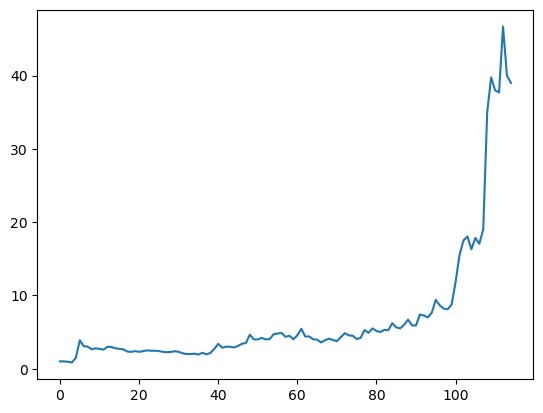

In [4]:
plt.plot(maybaker_end_month_df['close_price'])
plt.show()

In [5]:
maybaker_end_month_df['returns']=maybaker_end_month_df['close_price'].pct_change()*100
maybaker_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year,returns
0,45403,MAYBAKER,2017-01-31,1.00,1.00,138601,2026-04-08T02:43:03.07753+00:00,1,1,2017,NaN
1,47225,MAYBAKER,2017-02-28,1.00,1.00,4000,2026-04-08T02:44:45.006295+00:00,2,1,2017,0.000000
2,49341,MAYBAKER,2017-03-31,0.95,0.95,150400,2026-04-08T02:45:42.281198+00:00,3,1,2017,-5.000000
3,51168,MAYBAKER,2017-04-28,0.85,0.85,11400,2026-04-08T02:51:55.619599+00:00,4,2,2017,-10.526316
4,53091,MAYBAKER,2017-05-31,1.49,1.49,568015,2026-04-08T02:52:57.421655+00:00,5,2,2017,75.294118
...,...,...,...,...,...,...,...,...,...,...,...
110,35327,MAYBAKER,2026-03-31,38.00,38.00,788842,2026-03-31T15:00:02.085058+00:00,3,1,2026,-4.402516
111,281153,MAYBAKER,2026-04-30,37.70,37.70,1706180,2026-04-30T15:00:02.170664+00:00,4,2,2026,-0.789474
112,284219,MAYBAKER,2026-05-29,46.70,46.70,452486,2026-05-29T15:00:02.455558+00:00,5,2,2026,23.872679
113,294147,MAYBAKER,2026-06-30,40.00,40.00,234562,2026-06-30T15:10:03.08168+00:00,6,2,2026,-14.346895


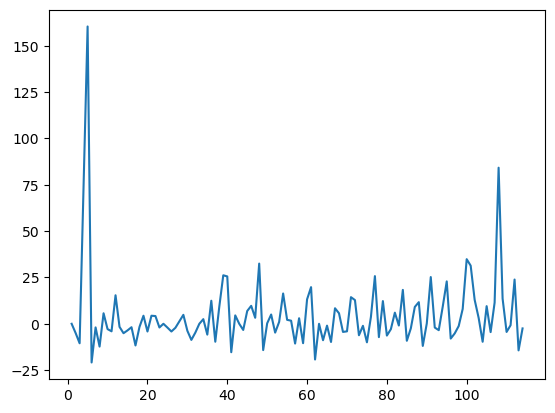

In [6]:
plt.plot(maybaker_end_month_df['returns'])
plt.show()

In [ ]:
## Test stationarity

from statsmodels.tsa.stattools import adfuller

result = adfuller(maybaker_end_month_df['returns'].dropna())
print(result)
pvalue = result[1]
if pvalue < 0.05:
    print('stationary')
else:
    print('not stationary')

(np.float64(-0.9293677275551283), np.float64(0.7781474477587416), 8, 88, {'1%': np.float64(-3.506944401824286), '5%': np.float64(-2.894989819214876), '10%': np.float64(-2.584614550619835)}, np.float64(646.9551762604126))
not stationary


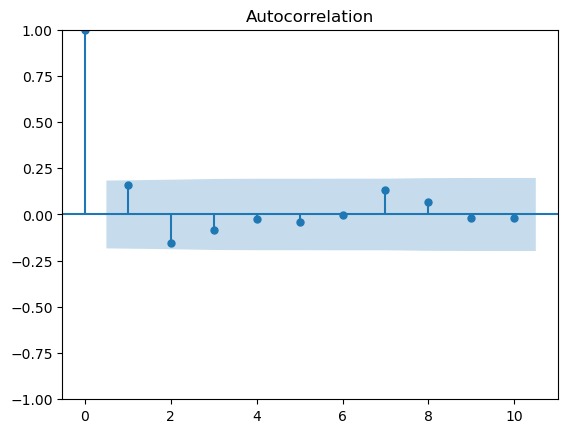

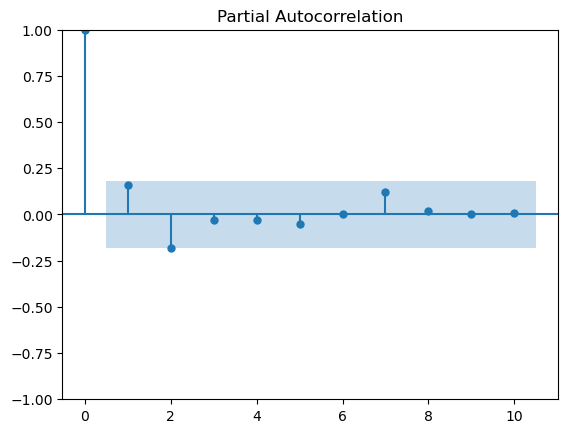

In [7]:
# Plotting the autocorrelation function and the partial autocorrelation function
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(maybaker_end_month_df['returns'].dropna(), lags=10)
plot_pacf(maybaker_end_month_df['returns'].dropna(), lags=10)
plt.show()

In [8]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=maybaker_end_month_df['close_price'][:-10]
test=maybaker_end_month_df['close_price'][-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -10.381816691600733]
[0, 0, 0, 0, 0, 1, -6.769441870021817]
[0, 0, 0, 0, 0, 2, -5.391071838326443]
[0, 0, 0, 0, 1, 0, -4.718838551379545]
[0, 0, 0, 0, 1, 1, -4.159887552186386]
[0, 0, 0, 0, 1, 2, -3.559889004831855]
[0, 0, 0, 0, 2, 0, -3.0121559116708605]
[0, 0, 0, 0, 2, 1, -3.196043564537203]
[0, 0, 0, 0, 2, 2, -3.196378679844563]
[0, 0, 0, 1, 0, 0, -4.972626854160379]
[0, 0, 0, 1, 0, 1, -4.491812325447167]
[0, 0, 0, 1, 0, 2, -3.9739551535142033]
[0, 0, 0, 1, 1, 0, -3.758001212118671]
[0, 0, 0, 1, 1, 1, -3.85801988090612]
[0, 0, 0, 1, 1, 2, -3.782049417629583]
[0, 0, 0, 1, 2, 0, -3.1748645084378326]
[0, 0, 0, 1, 2, 1, -3.093262936177223]
[0, 0, 0, 1, 2, 2, -3.234667443422932]
[0, 0, 0, 2, 0, 0, -4.307697499050584]
[0, 0, 0, 2, 0, 1, -4.3069268787318755]
[0, 0, 0, 2, 0, 2, -4.142273192210143]
[0, 0, 0, 2, 1, 0, -3.796280907139976]
[0, 0, 0, 2, 1, 1, -3.747592778530626]
[0, 0, 0, 2, 1, 2, -3.7663948751665988]
[0, 0, 0, 2, 2, 0, -3.1411285932047495]
[0, 0, 0, 2, 2, 1, 

In [9]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
0,0,0,0,0,0,0,-10.381817
540,2,0,2,0,0,0,-10.381817
27,0,0,1,0,0,0,-10.193247
54,0,0,2,0,0,0,-10.057780
171,0,2,0,1,0,0,-7.780839
...,...,...,...,...,...,...,...
702,2,2,2,0,0,0,-0.001684
707,2,2,2,0,1,2,0.074797
706,2,2,2,0,1,1,0.094454
710,2,2,2,0,2,2,0.183237


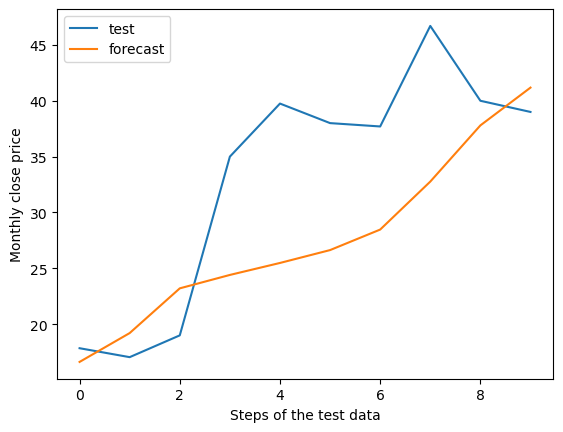

r2_score:  0.277876747784501
rmse:  8.704598089591576
description:  count    115.000000
mean       6.972261
std        9.130603
min        0.850000
25%        2.645000
50%        4.020000
75%        5.770000
max       46.700000
Name: close_price, dtype: float64


In [10]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

y_train=maybaker_end_month_df['close_price'][:-10]
y_test=maybaker_end_month_df['close_price'][-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(2,2,2), 
seasonal_order=(0,1,0,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly close price')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', maybaker_end_month_df.close_price.describe())

Captures the trend but. Its not capturing the variations properly. Lets try the returns

In [11]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=maybaker_end_month_df['returns'].dropna()[:-10]
test=maybaker_end_month_df['returns'].dropna()[-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -0.1932825934289304]
[0, 0, 0, 0, 0, 1, -0.19288158413432233]
[0, 0, 0, 0, 0, 2, -0.12245559243368387]
[0, 0, 0, 0, 1, 0, -0.7032458380495437]
[0, 0, 0, 0, 1, 1, -0.02262556992479059]
[0, 0, 0, 0, 1, 2, -0.009010705486387494]
[0, 0, 0, 0, 2, 0, -2.7189541682683562]
[0, 0, 0, 0, 2, 1, -1.0740244322970627]
[0, 0, 0, 0, 2, 2, -0.8504949171483442]
[0, 0, 0, 1, 0, 0, -0.1913606784337245]
[0, 0, 0, 1, 0, 1, -0.17889140125478886]
[0, 0, 0, 1, 0, 2, -0.12341269158115842]
[0, 0, 0, 1, 1, 0, -0.09820275748342278]
[0, 0, 0, 1, 1, 1, 0.0032185759996778973]
[0, 0, 0, 1, 1, 2, 0.11386576274467775]
[0, 0, 0, 1, 2, 0, -0.9489520692509537]
[0, 0, 0, 1, 2, 1, -0.6571052338510766]
[0, 0, 0, 1, 2, 2, -0.46961182226068376]
[0, 0, 0, 2, 0, 0, -0.11524635570776542]
[0, 0, 0, 2, 0, 1, -0.16994065231779687]
[0, 0, 0, 2, 0, 2, -0.03302920668211007]
[0, 0, 0, 2, 1, 0, -0.07023168524594459]
[0, 0, 0, 2, 1, 1, -0.05369575381479974]
[0, 0, 0, 2, 1, 2, 0.0026778364849403546]
[0, 0, 0, 2, 2, 0, -0.

In [12]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
188,0,2,0,2,2,2,-49.714914
177,0,2,0,1,2,0,-47.626739
653,2,2,0,0,2,0,-38.639032
186,0,2,0,2,2,0,-38.536195
187,0,2,0,2,2,1,-35.735885
...,...,...,...,...,...,...,...
499,2,0,0,1,1,2,0.055854
311,1,0,2,1,1,2,0.102123
236,0,2,2,2,0,2,0.105767
14,0,0,0,1,1,2,0.113866


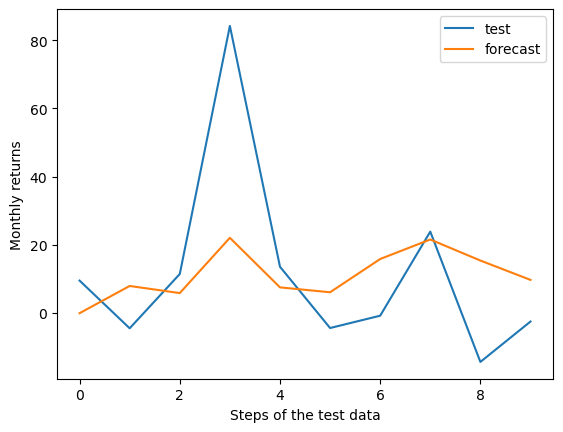

r2_score:  0.1965281076010662
rmse:  23.667194541447078
description:  count    114.000000
mean       4.719983
std       21.026395
min      -20.876289
25%       -4.461973
50%        0.000000
75%        9.160482
max      160.402685
Name: returns, dtype: float64


In [13]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

y_train=maybaker_end_month_df['returns'].dropna()[:-10]
y_test=maybaker_end_month_df['returns'].dropna()[-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(2,1,2), 
seasonal_order=(1,1,2,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly returns')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', maybaker_end_month_df.returns.dropna().describe())

Very horrible. We will work with close_price
